# Customer Churn Prediction

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from sklearn.ensemble import RandomForestClassifier

### Analysis of Data Set

In [25]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Rows are {df.shape[0]} and Coulumns are {df.shape[1]}")
print("Basic Info: \n" , df.info())
print("Summary: \n" , df.describe())
print("Checking for Missing Values: \n" , df.isnull().sum)

Rows are 7043 and Coulumns are 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Paperles

### Data Cleaning

In [9]:
df.rename(columns= {"gender" : "Gender"} ,inplace=True)
df.rename(columns={"customerID": "CustomerID"}, inplace=True)

df.drop(columns=["CustomerID"] , inplace=True)

df["TotalCharges"] = pd.to_numeric(df['TotalCharges'] , errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median() , inplace=True)

df["Churn"] = df["Churn"].map({"Yes":1 , "No":0})
df.head()


C:\Users\shkus\AppData\Local\Temp\ipykernel_10464\2784950146.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median() , inplace=True)


,Gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### Encoding

In [12]:
df_encoded = pd.get_dummies(df , drop_first=True)

### Train Test Split

In [13]:
X = df_encoded.drop("Churn" , axis=1)
y = df_encoded["Churn"]

X_train , X_test , y_train , y_test = train_test_split( X , y , test_size=0.2 , random_state=42)

### Scaling

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Model (Logistic Regression)

Logistic Regression Accuracy: 
 0.8197303051809794
classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



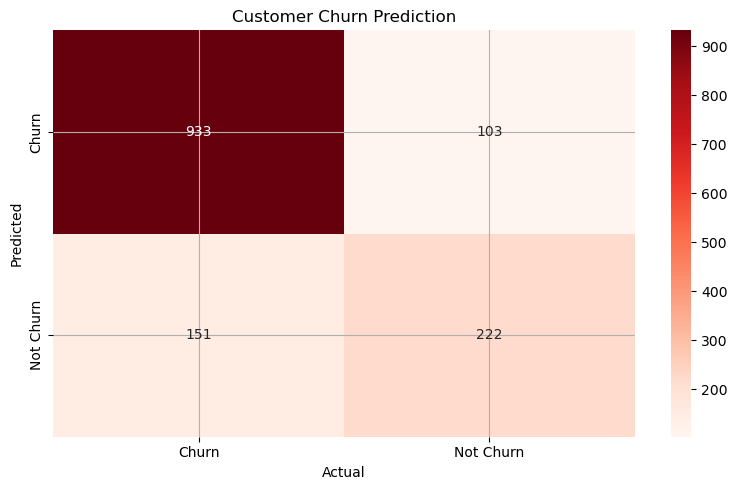

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled , y_train)

# ___________________MODEL ACCURACY AND EVALUATION________________

y_pred = model.predict(X_test_scaled)
print("Logistic Regression Accuracy: \n" , accuracy_score(y_test , y_pred))
print("classification Report: \n" , classification_report(y_test, y_pred))
conf_matrix = (confusion_matrix(y_test , y_pred))
plt.figure(figsize=(8 , 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["Churn" , "Not Churn"],
    yticklabels=["Churn" , "Not Churn"]
)
plt.title("Customer Churn Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid()
plt.tight_layout()
plt.show()

### Random Forest Classifier

Logistic Regression Accuracy: 
 0.8197303051809794
classification Report: 
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



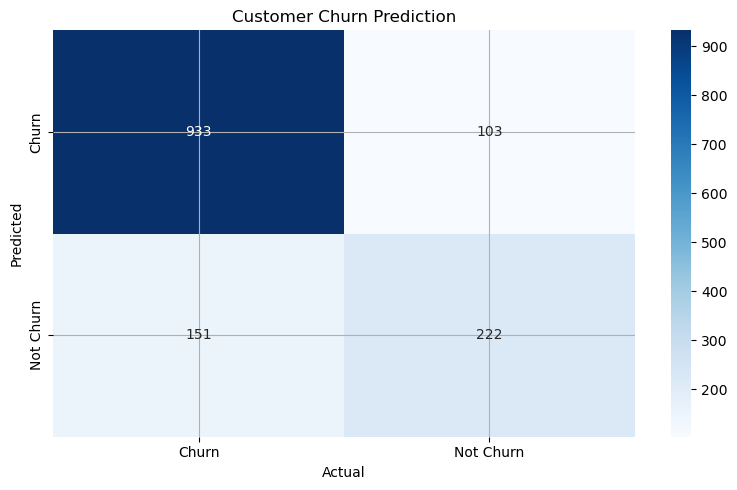

In [ ]:
rfc_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)
rfc_model.fit(X_train ,y_train)

# ___________________MODEL ACCURACY AND EVALUATION________________

y_pred = rfc_model.predict(X_test)
print("Random Forest Accuracy: \n" , accuracy_score(y_test , y_pred))
print("classification Report: \n" , classification_report(y_test, y_pred))
conf_matrix = (confusion_matrix(y_test , y_pred))
plt.figure(figsize=(8 , 5))
sns.heatmap(
    conf_matrix,annot=True,fmt="d",cmap="Blues",xticklabels=["Churn" , "Not Churn"],yticklabels=["Churn" , "Not Churn"]
)
plt.title("Customer Churn Prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid()
plt.tight_layout()
plt.show()

### Featuring Columns

In [23]:
feature_importance = pd.Series(
    rfc_model.feature_importances_,
    index = X.columns
).sort_values(ascending=False)

feature_importance.head()

TotalCharges                      0.196719
tenure                            0.170752
MonthlyCharges                    0.169223
PaymentMethod_Electronic check    0.036007
InternetService_Fiber optic       0.035989
dtype: float64